In [6]:
!pip install -q ftfy regex tqdm transformers
!pip install -q git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [7]:
!git clone https://github.com/okok0814/IT_Project.git
%cd IT_Project

Cloning into 'IT_Project'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 58 (delta 9), reused 51 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 2.82 MiB | 6.81 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/IT_Project


In [8]:
!ls data/d1/sample_images/

10180.jpg  2227.jpg   31105.jpg  34066.jpg  38947.jpg  49839.jpg  59759.jpg
13016.jpg  24408.jpg  31172.jpg  36203.jpg  41750.jpg  52125.jpg  8353.jpg
16806.jpg  2886.jpg   32812.jpg  38654.jpg  4727.jpg   54529.jpg


In [ ]:
!python3 scripts/clip_fashionclip_sanity_check.py

[CLIP] device = cuda
[CLIP] Encoded 20 ảnh + 3 câu truy vấn trong 1.99s (99.7 ms/ảnh)
[CLIP] Kích thước embedding ảnh: torch.Size([20, 512]), văn bản: torch.Size([3, 512])
[CLIP] Query: 'a white collared shirt' -> top-3: ['8353.jpg', '34066.jpg', '16806.jpg']
[CLIP] Query: 'áo sơ mi trắng công sở' -> top-3: ['31105.jpg', '4727.jpg', '32812.jpg']
[CLIP] Query: 'a pair of blue denim jeans' -> top-3: ['2227.jpg', '36203.jpg', '2886.jpg']
[FashionCLIP] device = cuda
Loading weights: 100% 398/398 [00:00<00:00, 5159.72it/s]
[FashionCLIP] Encoded 20 ảnh + 3 câu truy vấn trong 1.35s (67.6 ms/ảnh)
[FashionCLIP] Query: 'a white collared shirt' -> top-3: ['38654.jpg', '8353.jpg', '16806.jpg']
[FashionCLIP] Query: 'áo sơ mi trắng công sở' -> top-3: ['38947.jpg', '31172.jpg', '34066.jpg']
[FashionCLIP] Query: 'a pair of blue denim jeans' -> top-3: ['4727.jpg', '36203.jpg', '2227.jpg']



--- KẾT QUẢ CLIP ---


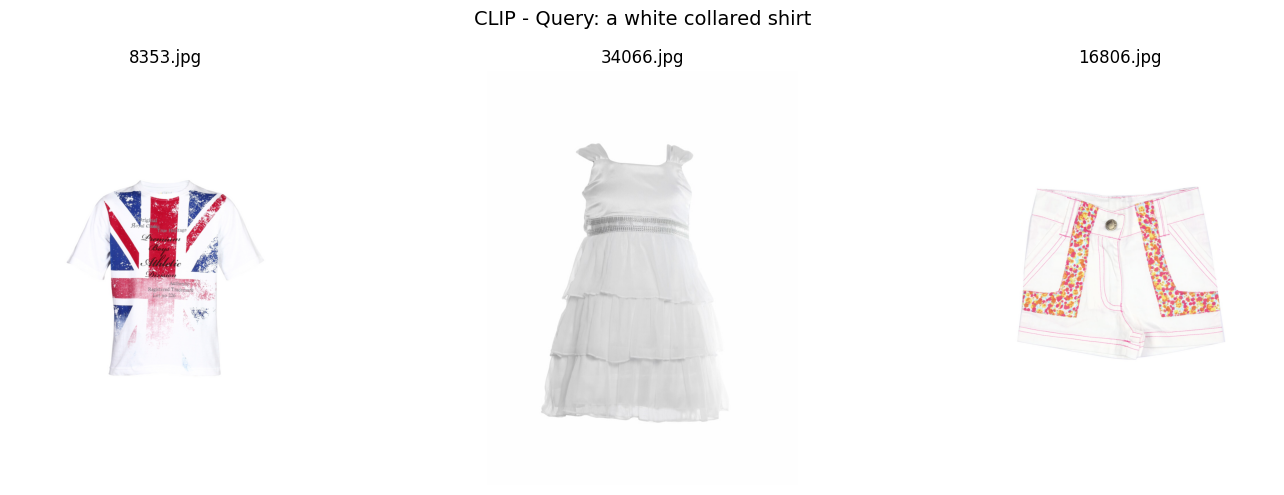

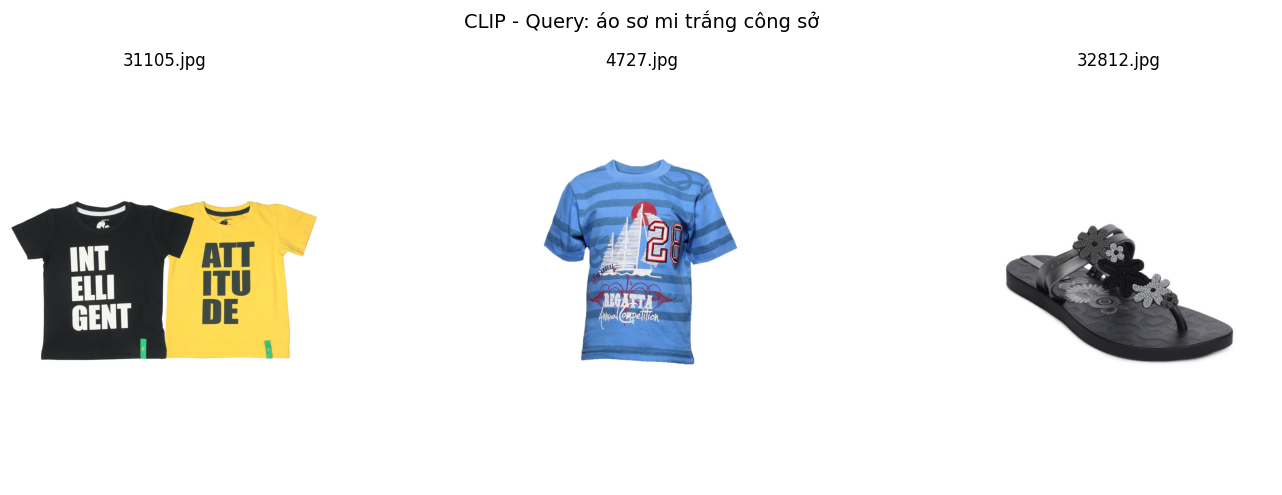

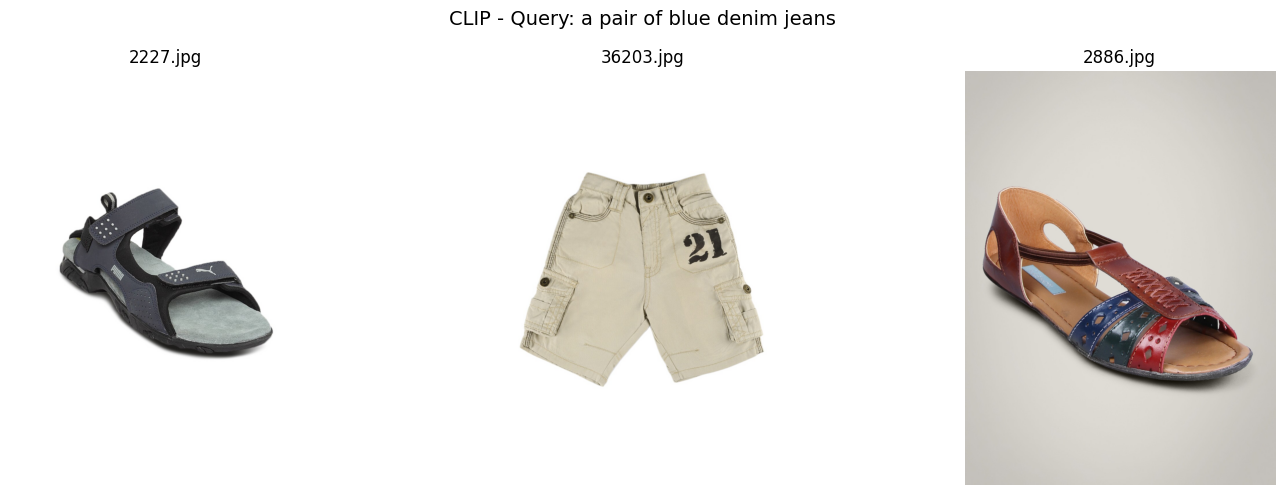


--- KẾT QUẢ FashionCLIP ---


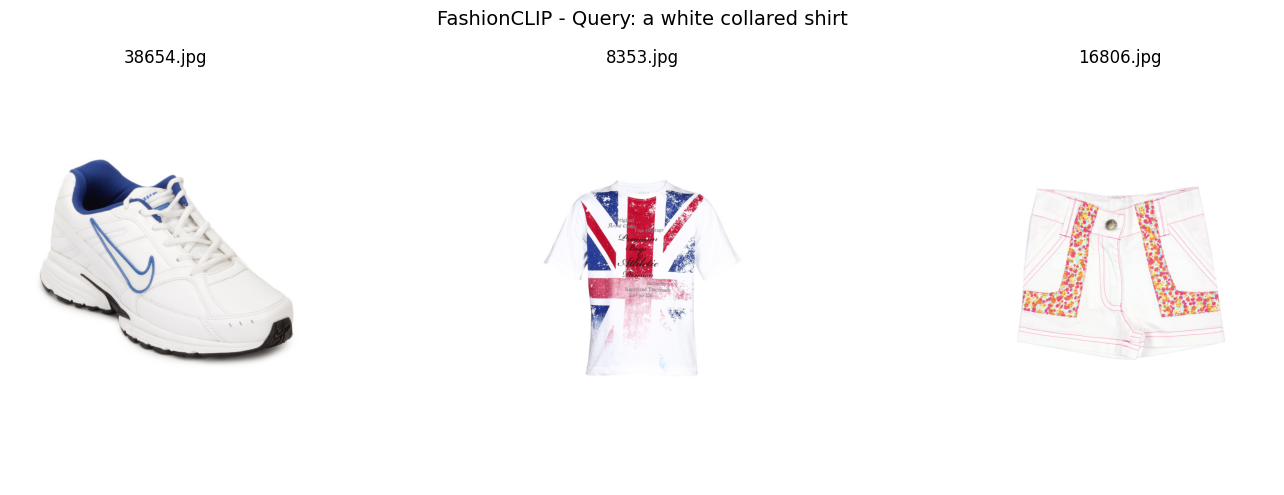

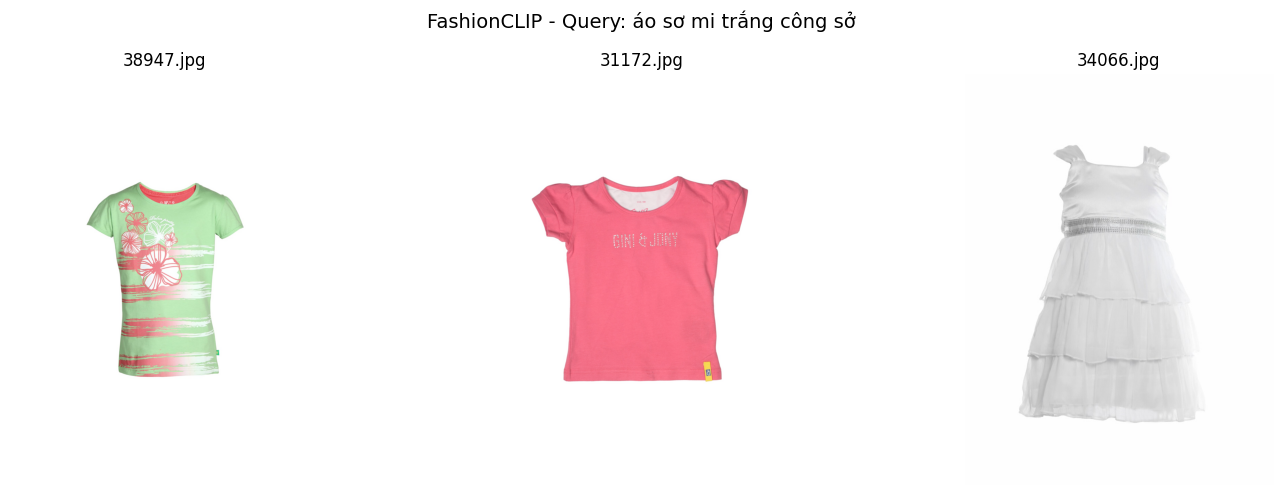

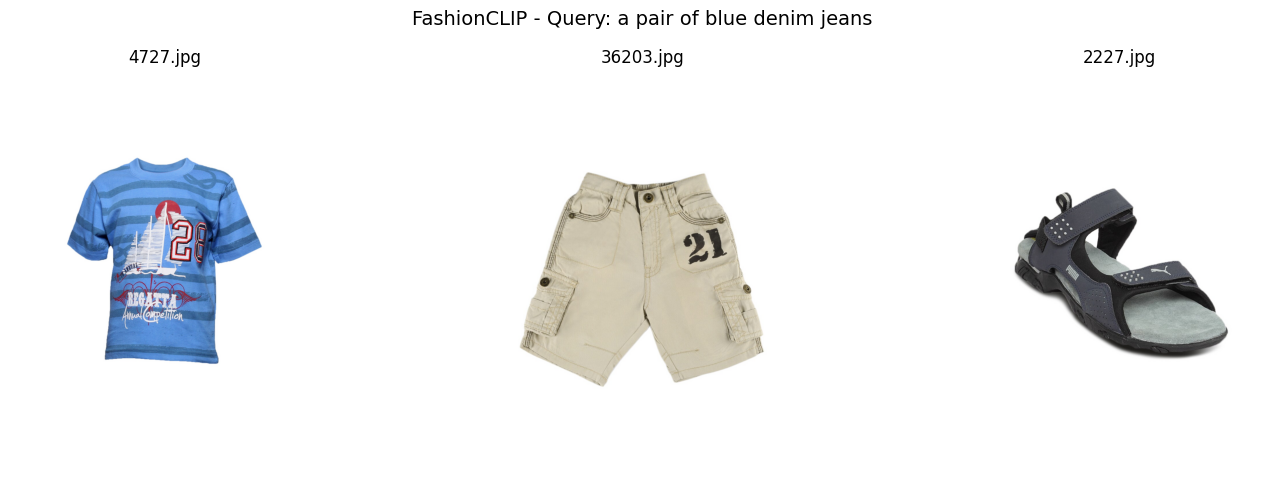

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Xác định đường dẫn gốc
base_dir = os.getcwd()
img_dir = os.path.join(base_dir, 'data/d1/sample_images/')

# Kết quả từ log sanity check
results_clip = {
    'a white collared shirt': ['8353.jpg', '34066.jpg', '16806.jpg'],
    'áo sơ mi trắng công sở': ['31105.jpg', '4727.jpg', '32812.jpg'],
    'a pair of blue denim jeans': ['2227.jpg', '36203.jpg', '2886.jpg']
}

results_fashionclip = {
    'a white collared shirt': ['38654.jpg', '8353.jpg', '16806.jpg'],
    'áo sơ mi trắng công sở': ['38947.jpg', '31172.jpg', '34066.jpg'],
    'a pair of blue denim jeans': ['4727.jpg', '36203.jpg', '2227.jpg']
}

queries = list(results_clip.keys())

def display_results(results, title_prefix):
    print(f"\n--- KẾT QUẢ {title_prefix} ---")
    for query in queries:
        images = results[query]
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"{title_prefix} - Query: {query}", fontsize=14)

        for i, img_name in enumerate(images):
            img_path = os.path.join(img_dir, img_name)
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                axes[i].imshow(img)
                axes[i].set_title(img_name)
                axes[i].axis('off')
            else:
                axes[i].text(0.5, 0.5, f'Not Found:\n{img_name}', ha='center')
                axes[i].axis('off')
        plt.tight_layout()
        plt.show()

display_results(results_clip, "CLIP")
display_results(results_fashionclip, "FashionCLIP")